### Pacotes importados

In [1]:
import Pkg
Pkg.add("Plots")

using Plots
using LinearAlgebra

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`


## Chapter 8: Quasi-Newton methods

### Algorithm 8.1: Finite difference Newton's method: one variable

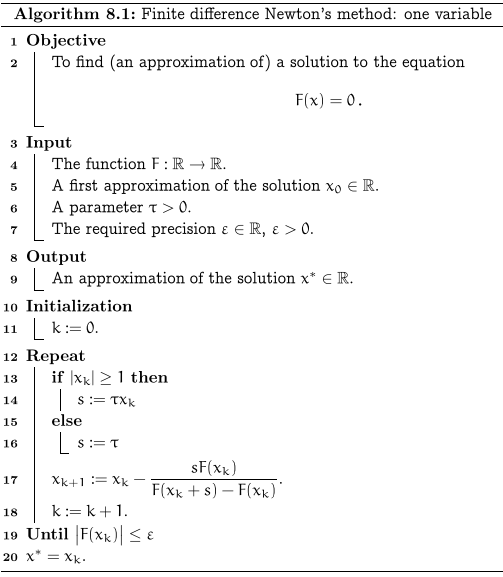

Example: $F(x)=x^2-2$. Run the example with $x_0=2$ and $\tau=10^{-7}$

In [9]:
function quasi_newton(F, x0, tau, epi; max_iter=100)
    x = x0
    xs = [x0]
    erros = [abs(F(x))]
    k = 0

    while abs(F(x)) > epi && k < max_iter
        if abs(x) >= 1
            s = tau * x
        else
            s = tau
        end

        x = x - (s * F(x)) / (F(x + s) - F(x))

        push!(xs, x)
        push!(erros, abs(F(x)))

        k += 1
    end

    return x, xs, erros, k
end

function plot_quasi_newton(F, x0, tau, epi; max_iter=100, titulo="Quasi-Newton")
    x_aprox, xs, erros, iter = quasi_newton(F, x0, tau, epi, max_iter=max_iter)

    k_vals = 0:length(xs)-1

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("|F(x)| final: ", abs(F(x_aprox)))

    p1 = plot(
        k_vals,
        xs,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="xₖ",
        title="Convergência - $titulo",
        label="xₖ"
    )

    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="|F(xₖ)|",
        title="Erro por iteração - $titulo",
        label="Erro"
    )

    display(p1)
    display(p2)

    return x_aprox, iter, xs, erros
end

plot_quasi_newton (generic function with 1 method)

Solução aproximada: 1.414213562374796
Iterações: 4
|F(x)| final: 4.810818410305728e-12


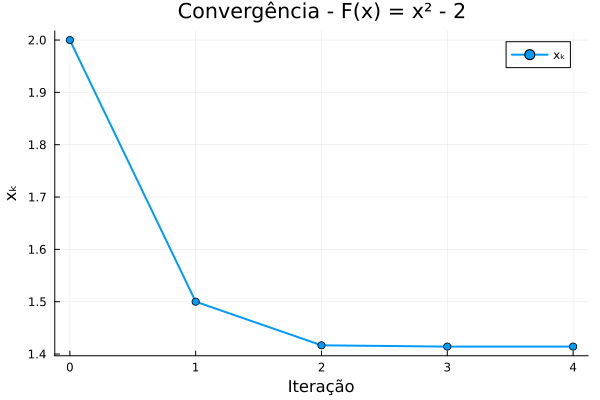

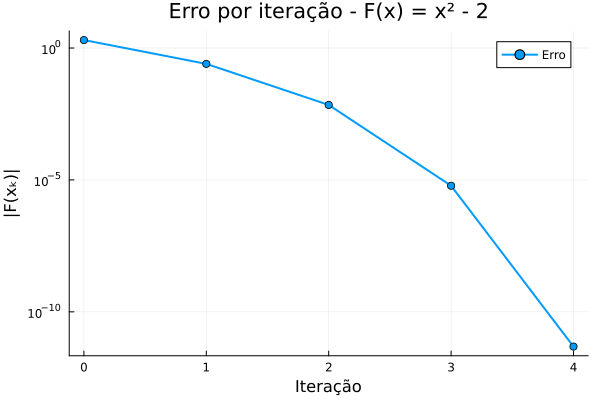

(1.414213562374796, 4, [2.0, 1.5000000252719503, 1.4166666722399401, 1.4142156864080049, 1.414213562374796], [2.0, 0.2500000758158514, 0.006944460235386085, 6.007682464392872e-6, 4.810818410305728e-12])

In [12]:
F(x) = x^2 - 2

x0 = 2.0
tau = 1e-7
epi = 1e-10

plot_quasi_newton(F, 2.0, 1e-7, 1e-10, titulo="F(x) = x² - 2")

Run the example with $x_0=2$ and $\tau=0.1$

Solução aproximada: 1.4142135623784085
Iterações: 9
|F(x)| final: 1.502842295053597e-11


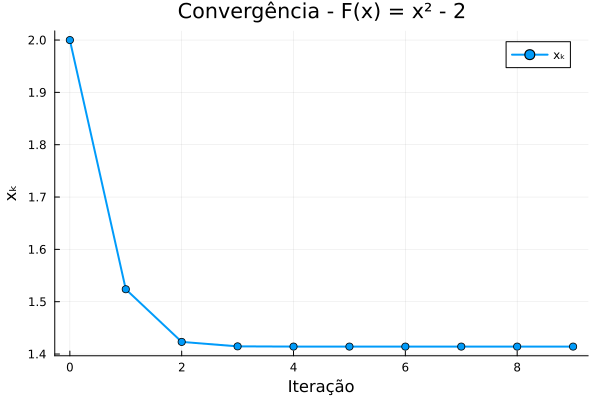

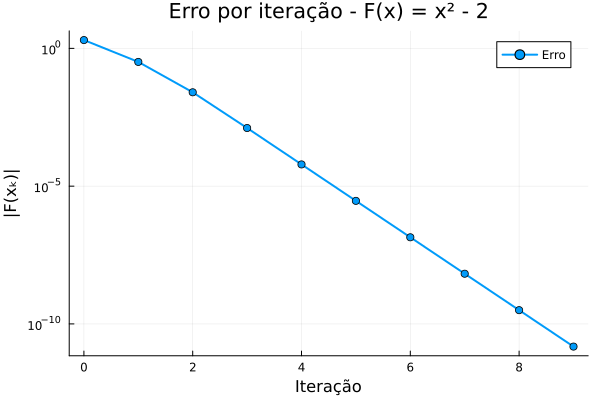

(1.4142135623784085, 9, [2.0, 1.5238095238095242, 1.423185941043084, 1.4146677545712822, 1.4142352600123498, 1.4142145957525318, 1.4142136115819992, 1.414213564716377, 1.4142135624846799, 1.4142135623784085], [2.0, 0.32199546485260866, 0.025458222782688722, 0.0012848558237537056, 6.137066219880083e-5, 2.922839497099261e-6, 1.391838018172109e-7, 6.627801862890692e-9, 3.15609760548341e-10, 1.502842295053597e-11])

In [13]:
F(x) = x^2 - 2

x0 = 2.0
tau = 0.1
epi = 1e-10

plot_quasi_newton(F, 2.0, 0.1, 1e-10, titulo="F(x) = x² - 2")

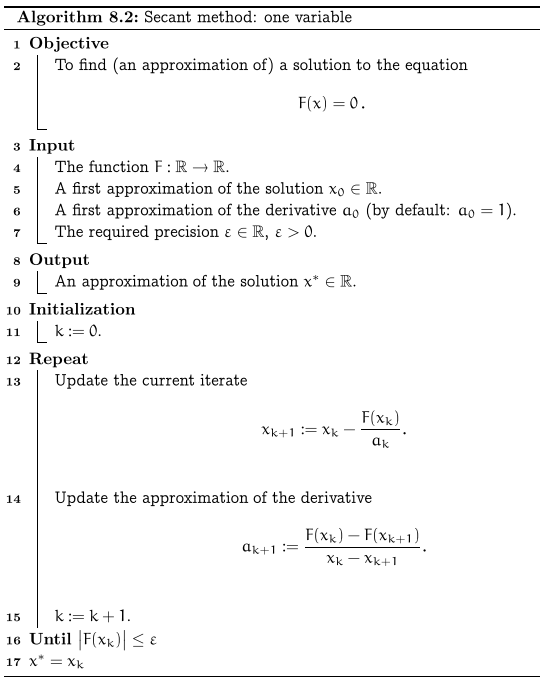

Example: $F(x)=x^2-2$, with $x_0=2$ and $a_0=1$

In [17]:
function secante(F, x0, a0, epi; max_iter=100)
    x = x0
    a = a0

    xs = [x0]
    erros = [abs(F(x))]

    k = 0

    while abs(F(x)) > epi && k < max_iter
        x_new = x - F(x)/a

        a = (F(x) - F(x_new)) / (x - x_new)

        x = x_new

        push!(xs, x)
        push!(erros, abs(F(x)))

        k += 1
    end

    return x, xs, erros, k
end

function plot_secante(F, x0, a0, epi; max_iter=100, titulo="Secante")
    x_aprox, xs, erros, iter = secante(F, x0, a0, epi, max_iter=max_iter)

    k_vals = 0:length(xs)-1

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("|F(x)| final: ", abs(F(x_aprox)))

    p1 = plot(
        k_vals,
        xs,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="xₖ",
        title="Convergência - $titulo",
        label="xₖ"
    )

    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="|F(xₖ)|",
        title="Erro por iteração - $titulo",
        label="Erro"
    )

    display(p1)
    display(p2)

    return x_aprox, iter
end


plot_secante (generic function with 1 method)

Solução aproximada: 1.4142135623730954
Iterações: 9
|F(x)| final: 8.881784197001252e-16


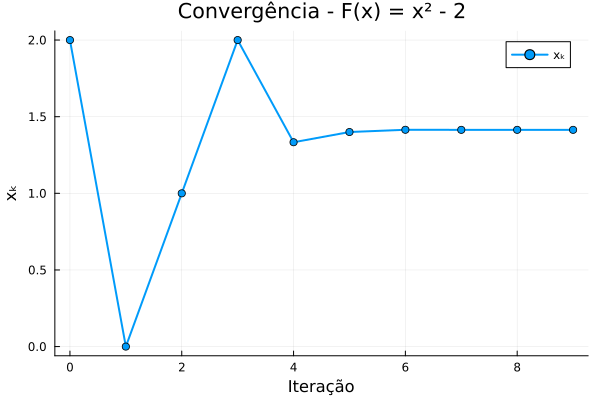

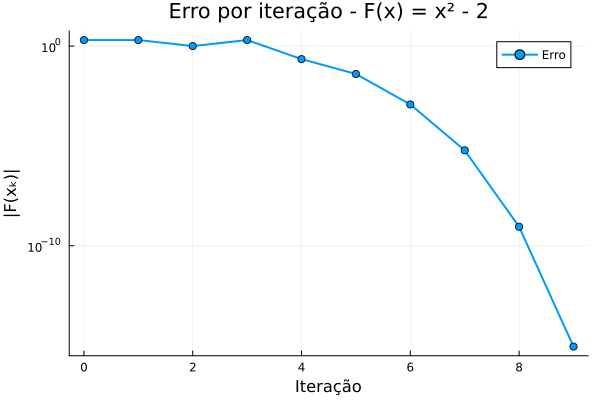

(1.4142135623730954, 9)

In [18]:
F(x) = x^2 - 2

plot_secante(F, 2.0, 1.0, 1e-10, titulo="F(x) = x² - 2")

### Algorithm 8.3: finite difference Newton's method: $n$ variables

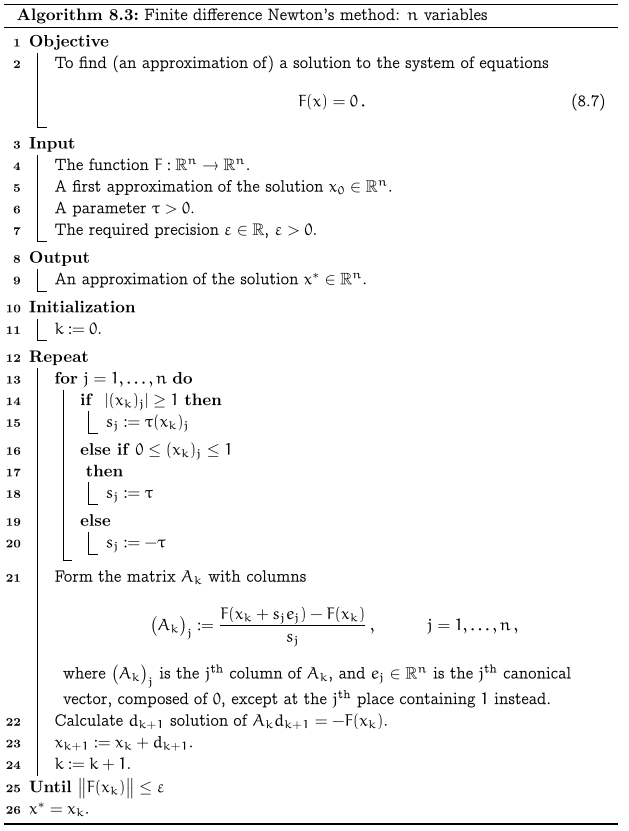

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=10^{-7}$

In [20]:
function newton_fd_sistema_plot(F, x0, tau, epi; max_iter=100)
    x = copy(x0)
    n = length(x)

    xs = [copy(x)]
    erros = [norm(F(x))]

    k = 0

    while norm(F(x)) > epi && k < max_iter
        A = zeros(n, n)

        for j in 1:n
            if abs(x[j]) >= 1
                s = tau * x[j]
            elseif x[j] >= 0
                s = tau
            else
                s = -tau
            end

            ej = zeros(n)
            ej[j] = 1.0

            A[:, j] = (F(x + s*ej) - F(x)) / s
        end

        d = A \ (-F(x))
        x = x + d

        push!(xs, copy(x))
        push!(erros, norm(F(x)))

        k += 1
    end

    return x, xs, erros, k
end

function plot_newton_fd_sistema(F, x0, tau, epi; max_iter=100, titulo="Newton FD Sistema")
    x_aprox, xs, erros, iter = newton_fd_sistema_plot(F, x0, tau, epi, max_iter=max_iter)

    k_vals = 0:length(xs)-1
    x1_vals = [x[1] for x in xs]
    x2_vals = [x[2] for x in xs]

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("Norma final: ", norm(F(x_aprox)))

    p1 = plot(
        k_vals,
        x1_vals,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="Valor",
        title="Convergência - $titulo",
        label="x₁"
    )

    plot!(
        p1,
        k_vals,
        x2_vals,
        marker=:diamond,
        linewidth=2,
        label="x₂"
    )

    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="||F(xₖ)||",
        title="Erro - $titulo",
        label="Erro"
    )

    display(p1)
    display(p2)

    return x_aprox, iter
end

plot_newton_fd_sistema (generic function with 1 method)

Solução aproximada: [-5.688115880764325e-12, 1.0000000000111586]
Iterações: 5
Norma final: 2.9863924458983494e-11


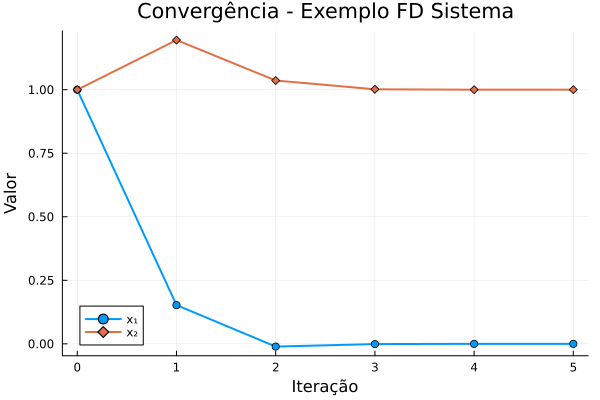

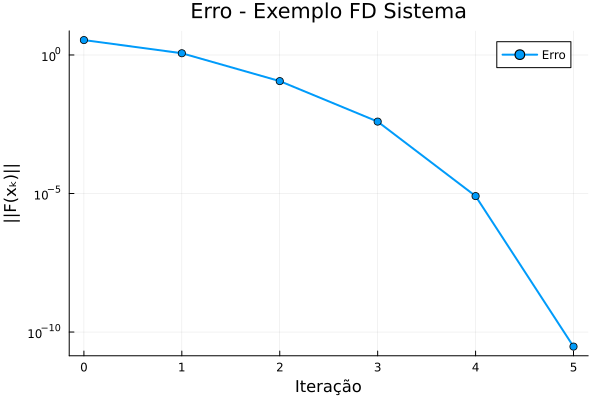

([-5.688115880764325e-12, 1.0000000000111586], 5)

In [21]:
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2;
    exp(x[1]) + x[2]^3 - 2
]

x0 = [1.0, 1.0]
tau = 1e-7
epi = 1e-10

plot_newton_fd_sistema(F, x0, tau, epi, titulo="Exemplo FD Sistema")

Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=0.1$

Solução aproximada: [-1.892610821166677e-12, 1.0000000000042684]
Iterações: 13
Norma final: 1.1902272920490916e-11


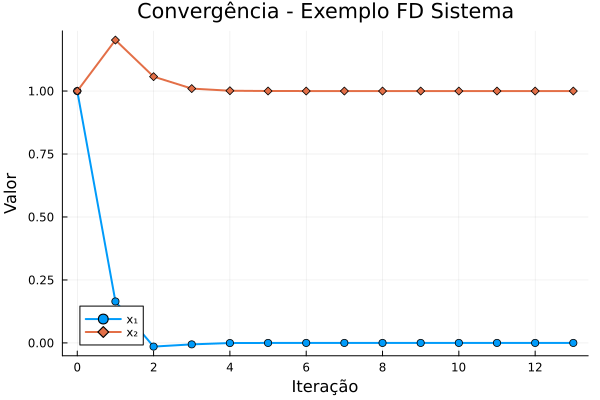

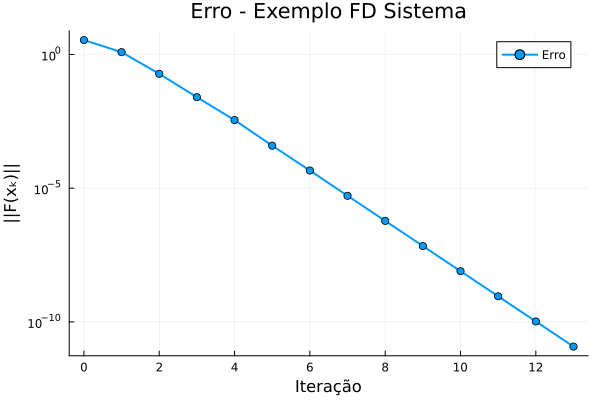

([-1.892610821166677e-12, 1.0000000000042684], 13)

In [22]:
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2;
    exp(x[1]) + x[2]^3 - 2
]

x0 = [1.0, 1.0]
tau = 0.1
epi = 1e-10

plot_newton_fd_sistema(F, x0, tau, epi, titulo="Exemplo FD Sistema")

### Algorithm 8.4: secant method: $n$ variables

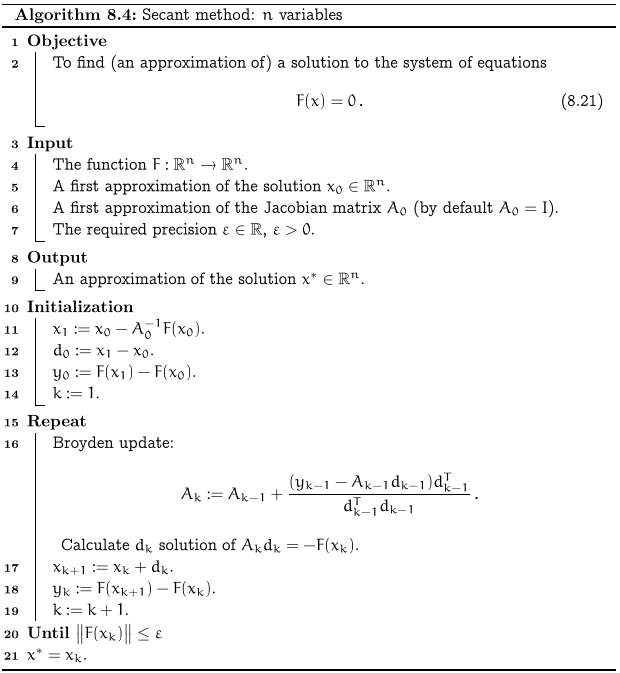

Example 7.11: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$, $x_0=\left(\begin{array}{c} 1 \\ 1 \end{array}\right)$


In [23]:
function secante_sistema_plot(F, x0, A0, epi; max_iter=100)
    x_ant = copy(x0)
    A = copy(A0)

    x = x_ant - A \ F(x_ant)

    d_ant = x - x_ant
    y_ant = F(x) - F(x_ant)

    xs = [copy(x_ant), copy(x)]
    erros = [norm(F(x_ant)), norm(F(x))]

    k = 1

    while norm(F(x)) > epi && k < max_iter
        A = A + ((y_ant - A*d_ant) * d_ant') / (d_ant' * d_ant)

        d = A \ (-F(x))

        x_novo = x + d
        y = F(x_novo) - F(x)

        x_ant = x
        x = x_novo
        d_ant = d
        y_ant = y

        push!(xs, copy(x))
        push!(erros, norm(F(x)))

        k += 1
    end

    return x, xs, erros, k
end
function plot_secante_sistema(F, x0, A0, epi; max_iter=100, titulo="Secante Sistema")
    x_aprox, xs, erros, iter = secante_sistema_plot(F, x0, A0, epi, max_iter=max_iter)

    k_vals = 0:length(xs)-1
    x1_vals = [x[1] for x in xs]
    x2_vals = [x[2] for x in xs]

    println("Solução aproximada: ", x_aprox)
    println("Iterações: ", iter)
    println("Norma final: ", norm(F(x_aprox)))

    p1 = plot(
        k_vals,
        x1_vals,
        marker=:circle,
        linewidth=2,
        xlabel="Iteração",
        ylabel="Valor",
        title="Convergência - $titulo",
        label="x₁"
    )

    plot!(
        p1,
        k_vals,
        x2_vals,
        marker=:diamond,
        linewidth=2,
        label="x₂"
    )

    p2 = plot(
        k_vals,
        erros,
        marker=:circle,
        linewidth=2,
        yscale=:log10,
        xlabel="Iteração",
        ylabel="||F(xₖ)||",
        title="Erro - $titulo",
        label="Erro"
    )

    display(p1)
    display(p2)

    return x_aprox, iter
end

plot_secante_sistema (generic function with 1 method)

Solução aproximada: [-1.7137474114864595, 1.2208868221896985]
Iterações: 17
Norma final: 1.3080368562597357e-13


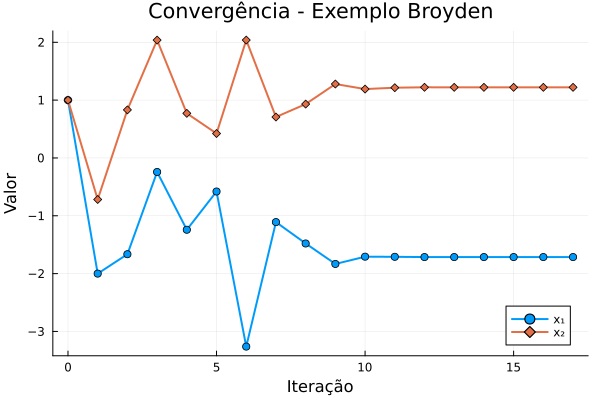

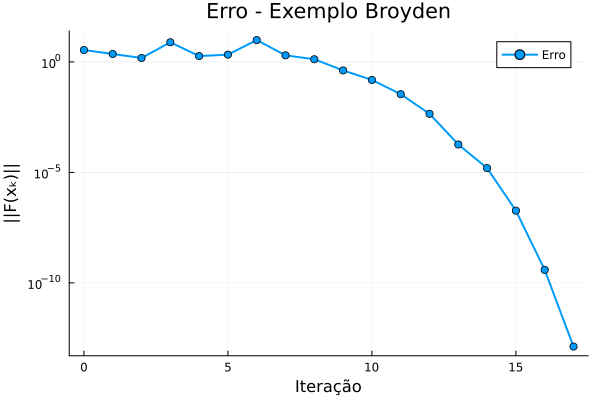

([-1.7137474114864595, 1.2208868221896985], 17)

In [24]:
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2;
    exp(x[1]) + x[2]^3 - 2
]

x0 = [1.0, 1.0]
A0 = Matrix{Float64}(I, 2, 2)
epi = 1e-10

plot_secante_sistema(F, x0, A0, epi, titulo="Exemplo Broyden")